# 1. Data loading & train/valid/test split

In [3]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
 
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier as SklearnDTC
from sklearn.metrics import roc_auc_score
import category_encoders as ce
 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
def roc_auc_custom(y_true, y_score):
    y_true, y_score = np.asarray(y_true), np.asarray(y_score)
    order = np.argsort(y_score)[::-1]
    y_sorted = y_true[order]
    n_pos = y_true.sum(); n_neg = len(y_true) - n_pos
    tps = np.cumsum(y_sorted); fps = np.cumsum(1 - y_sorted)
    tpr = np.concatenate([[0], tps / n_pos])
    fpr = np.concatenate([[0], fps / n_neg])
    return float(np.trapezoid(tpr, fpr))
 
def gini(y_true, y_score):
    return 2 * roc_auc_custom(y_true, y_score) - 1

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

In [5]:
df = pd.read_csv("data/training.csv")
df["PurchDate"] = pd.to_datetime(df["PurchDate"])
df = df.sort_values("PurchDate").reset_index(drop=True)
 
dates = df["PurchDate"].unique()
n = len(dates)
t1 = dates[int(n / 3)]
t2 = dates[int(2 * n / 3)]
 
train = df[df["PurchDate"] < t1].copy()
valid = df[(df["PurchDate"] >= t1) & (df["PurchDate"] < t2)].copy()
test = df[df["PurchDate"] >= t2].copy()
 
print(f"Train: {len(train)} | Valid: {len(valid)} | Test: {len(test)}")

Train: 23059 | Valid: 24104 | Test: 25820


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   RefId                              72983 non-null  int64         
 1   IsBadBuy                           72983 non-null  int64         
 2   PurchDate                          72983 non-null  datetime64[ns]
 3   Auction                            72983 non-null  object        
 4   VehYear                            72983 non-null  int64         
 5   VehicleAge                         72983 non-null  int64         
 6   Make                               72983 non-null  object        
 7   Model                              72983 non-null  object        
 8   Trim                               70623 non-null  object        
 9   SubModel                           72975 non-null  object        
 10  Color                             

In [7]:
df.select_dtypes(include=['object', 'category']).columns.to_list()

['Auction',
 'Make',
 'Model',
 'Trim',
 'SubModel',
 'Color',
 'Transmission',
 'WheelType',
 'Nationality',
 'Size',
 'TopThreeAmericanName',
 'PRIMEUNIT',
 'AUCGUART',
 'VNST']

In [ ]:
TARGET = "IsBadBuy"
DROP = ["RefId", "IsBadBuy", "PurchDate"]
 
CAT_COLS = ["Auction", "Make", "Model", "Trim", "SubModel", "Color", "Transmission",
            "WheelType", "Nationality", "Size", "TopThreeAmericanName",
            "PRIMEUNIT", "AUCGUART", "VNST"]
NUM_COLS = [c for c in df.columns if c not in CAT_COLS + DROP]

for col in CAT_COLS:
    train[col] = train[col].fillna('MISSING').astype(str)
    valid[col] = valid[col].fillna('MISSING').astype(str)
    test[col] = test[col].fillna('MISSING').astype(str)

y_train = train[TARGET].values
y_valid = valid[TARGET].values
y_test = test[TARGET].values

In [ ]:
oov_cols = []
for col in CAT_COLS:
    oov = set(valid[col].astype(str)) - set(train[col].astype(str))
    if oov: oov_cols.append(col)
print(f"  Columns with OOV values: {oov_cols[:]} ({len(oov_cols)} total)")

  Columns with OOV values: ['Make', 'Model', 'Trim', 'SubModel', 'Transmission', 'Nationality', 'Size', 'TopThreeAmericanName', 'PRIMEUNIT', 'VNST'] (10 total)


In [10]:
count_enc = ce.CountEncoder(cols=CAT_COLS, handle_unknown="value",
                            handle_missing="value", normalize=False)
count_enc.fit(train[CAT_COLS])
 
def make_X(split_df, medians=None, fit_medians=False):
    cat = count_enc.transform(split_df[CAT_COLS].copy())
    num = split_df[NUM_COLS].copy()
    X = pd.concat([num.reset_index(drop=True), cat.reset_index(drop=True)], axis=1)
    X = X.replace([np.inf, -np.inf], np.nan)
    if fit_medians:
        medians = X.median()
    X = X.fillna(medians)
    return X.values.astype(float), medians
 
X_train, medians = make_X(train, fit_medians=True)
X_valid, _ = make_X(valid, medians=medians)
X_test,  _ = make_X(test, medians=medians)
print(f"  Feature matrix: {X_train.shape[1]} features")

  Feature matrix: 31 features


# 2. Custom Decision Tree

In [11]:
class Node:
    """
    A single node in a decision tree.
 
    Classifier: uses Gini impurity.
    Regressor: uses standard deviation (MSE proxy).
    """
    def __init__(self, X, y, depth=0, is_classifier=True):
        self.X = X
        self.y = y
        self.depth = depth
        self.is_classifier = is_classifier
        self.left = None
        self.right = None
        self.feature_idx = None # split feature index
        self.threshold = None # split threshold
        self.value = None # leaf value (class proba or mean)

    @staticmethod
    def gini_impurity(y):
        """Gini = 1 - Σ p_k²"""
        if len(y) == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        p = counts / counts.sum()
        return 1.0 - float((p ** 2).sum())
 
    @staticmethod
    def std_impurity(y):
        """Standard deviation — used for regression."""
        return float(np.std(y)) if len(y) > 1 else 0.0
 
    def impurity(self, y):
        return self.gini_impurity(y) if self.is_classifier else self.std_impurity(y)
 
    def compute_leaf_value(self):
        if self.is_classifier:
            self.value = float(self.y.mean()) if len(self.y) > 0 else 0.0 # proba of class 1
        else:
            self.value = float(self.y.mean()) if len(self.y) > 0 else 0.0
 
    @property
    def is_leaf(self):
        return self.left is None and self.right is None

In [ ]:
MAX_BINS = 32
 
def find_best_split(node, min_samples_leaf=1):
    """
    Optimized split search using histogram binning (≤ MAX_BINS thresholds per feature).
    Equivalent to exact search when MAX_BINS >= n_unique_values.
    """
    X, y = node.X, node.y
    n, d = X.shape
    best_gain = -np.inf
    best_feat = None
    best_thr = None
 
    parent_impurity = node.impurity(y)
    if parent_impurity == 0.0:
        return None, None, -np.inf
 
    for feat in range(d):
        values = X[:, feat]
        unique_vals = np.unique(values)
        if len(unique_vals) < 2:
            continue
 
        # Bin thresholds: at most MAX_BINS midpoints
        if len(unique_vals) > MAX_BINS + 1:
            # Use quantile-based binning
            quantiles = np.linspace(0, 100, MAX_BINS + 2)[1:-1]
            thresholds = np.unique(np.percentile(values, quantiles))
        else:
            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2
 
        # Vectorized gain calculation for this feature
        order = np.argsort(values)
        y_sorted = y[order]
        v_sorted = values[order]
 
        # Cumulative sums for fast impurity calculation
        cum_sum = np.cumsum(y_sorted) # cumsum of positive labels
 
        for thr in thresholds:
            split_pos = np.searchsorted(v_sorted, thr, side='right')
            n_l = split_pos
            n_r = n - split_pos
            if n_l < min_samples_leaf or n_r < min_samples_leaf:
                continue
 
            if node.is_classifier:
                # Gini impurity using cumulative counts
                p_l = cum_sum[n_l - 1] / n_l
                p_r = (cum_sum[-1] - cum_sum[n_l - 1]) / n_r
                imp_l = 1.0 - p_l**2 - (1 - p_l)**2
                imp_r = 1.0 - p_r**2 - (1 - p_r)**2
            else:
                # Std impurity
                sum_l = cum_sum[n_l - 1]
                sum_r = cum_sum[-1] - sum_l
                mean_l = sum_l / n_l
                mean_r = sum_r / n_r
                # Var = E[x^2] - (E[x])^2
                cum_sq = np.cumsum(y_sorted ** 2)
                sq_l = cum_sq[n_l - 1]
                sq_r = cum_sq[-1] - sq_l
                imp_l = np.sqrt(max(sq_l / n_l - mean_l**2, 0))
                imp_r = np.sqrt(max(sq_r / n_r - mean_r**2, 0))

            gain = parent_impurity - (n_l / n) * imp_l - (n_r / n) * imp_r
            if gain > best_gain:
                best_gain = gain
                best_feat = feat
                best_thr = thr
 
    return best_feat, best_thr, best_gain
 
 
def find_random_split(node, min_samples_leaf=1):
    """
    Extra-Trees: for each feature pick ONE random threshold uniformly in [min, max].
    Then return the best among all features (still a valid random split).
    """
    X, y = node.X, node.y
    n, d = X.shape
    best_gain = -np.inf
    best_feat = None
    best_thr = None

    parent_impurity = node.impurity(y)
    if parent_impurity == 0.0:
        return None, None, -np.inf
 
    for feat in np.random.permutation(d):
        values = X[:, feat]
        lo, hi = values.min(), values.max()
        if lo == hi:
            continue
        thr = np.random.uniform(lo, hi)
 
        left_mask = values <= thr
        n_l, n_r = left_mask.sum(), (~left_mask).sum()
        if n_l < min_samples_leaf or n_r < min_samples_leaf:
            continue
 
        y_l, y_r = y[left_mask], y[~left_mask]
        gain = parent_impurity - (n_l/n)*node.impurity(y_l) - (n_r/n)*node.impurity(y_r)
        if gain > best_gain:
            best_gain = gain
            best_feat = feat
            best_thr = thr

    return best_feat, best_thr, best_gain
 
 
def _build_tree(node, max_depth, min_samples_leaf, split_fn):
    """Recursively grow the tree."""
    node.compute_leaf_value()
 
    # Stopping conditions
    if (node.depth >= max_depth
            or len(node.y) < 2 * min_samples_leaf
            or node.impurity(node.y) == 0.0):
        return
 
    feat, thr, gain = split_fn(node, min_samples_leaf)
    if feat is None or gain <= 0:
        return
 
    node.feature_idx = feat
    node.threshold = thr

    left_mask = node.X[:, feat] <= thr
    right_mask = ~left_mask

    node.left = Node(node.X[left_mask], node.y[left_mask],
                     node.depth + 1, node.is_classifier)
    node.right = Node(node.X[right_mask], node.y[right_mask],
                      node.depth + 1, node.is_classifier)
 
    # Free data at internal nodes to save memory
    node.X = None
    node.y = None

    _build_tree(node.left, max_depth, min_samples_leaf, split_fn)
    _build_tree(node.right, max_depth, min_samples_leaf, split_fn)
 
 
def _predict_one(node, x):
    """Traverse tree for a single sample."""
    while not node.is_leaf:
        if x[node.feature_idx] <= node.threshold:
            node = node.left
        else:
            node = node.right
    return node.value

In [ ]:
class DecisionTreeClassifier:
    """
    Binary Decision Tree Classifier using Gini impurity.
    Supports exhaustive best-split search (standard) or random split (Extra-Tree).
    """
    def __init__(self, max_depth=5, min_samples_leaf=1,
                 extra_random=False, max_features=None, random_state=None):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.extra_random = extra_random
        self.max_features = max_features # if set, subsample features
        self.random_state = random_state
        self.root_ = None

    def _subsample_features(self, X):
        """Optionally restrict to random subset of features."""
        if self.max_features is None or self.max_features >= X.shape[1]:
            return X, np.arange(X.shape[1])
        k = max(1, int(self.max_features))
        chosen = np.random.choice(X.shape[1], k, replace=False)
        return X[:, chosen], chosen
 
    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        X_use, self.feat_idx_ = self._subsample_features(X)
        self.root_ = Node(X_use, np.asarray(y, dtype=float),
                          depth=0, is_classifier=True)
        split_fn = find_random_split if self.extra_random else find_best_split
        _build_tree(self.root_, self.max_depth, self.min_samples_leaf, split_fn)
        return self
 
    def predict_proba(self, X):
        X_use = X[:, self.feat_idx_]
        probs = np.array([_predict_one(self.root_, x) for x in X_use])
        return np.column_stack([1 - probs, probs])
 
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


class DecisionTreeRegressor:
    """
    Decision Tree Regressor using Std (MSE proxy) as split criterion.
    Used internally by GBDT.
    """
    def __init__(self, max_depth=3, min_samples_leaf=1,
                 extra_random=False, max_features=None):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.extra_random = extra_random
        self.max_features = max_features
        self.root_ = None
        self.feat_idx_ = None

    def fit(self, X, y):
        if self.max_features is not None and self.max_features < X.shape[1]:
            k = max(1, int(self.max_features))
            self.feat_idx_ = np.random.choice(X.shape[1], k, replace=False)
        else:
            self.feat_idx_ = np.arange(X.shape[1])
        X_use = X[:, self.feat_idx_]
        self.root_ = Node(X_use, np.asarray(y, dtype=float),
                          depth=0, is_classifier=False)
        split_fn = find_random_split if self.extra_random else find_best_split
        _build_tree(self.root_, self.max_depth, self.min_samples_leaf, split_fn)
        return self
 
    def predict(self, X):
        X_use = X[:, self.feat_idx_]
        return np.array([_predict_one(self.root_, x) for x in X_use])
 

class ExtraRandomizedTreeClassifier(DecisionTreeClassifier):
    """Thin wrapper: forces extra_random=True."""
    def __init__(self, max_depth=5, min_samples_leaf=1,
                 max_features=None, random_state=None):
        super().__init__(max_depth=max_depth,
                         min_samples_leaf=min_samples_leaf,
                         extra_random=True,
                         max_features=max_features,
                         random_state=random_state)

# 3. Custom DT in use, checking Gini on validation data

In [14]:
dt_custom = DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)
dt_custom.fit(X_train, y_train)
prob_dt = dt_custom.predict_proba(X_valid)[:, 1]
gini_dt = gini(y_valid, prob_dt)
print(f"Custom DTC: Gini valid = {gini_dt:.4f}")

Custom DTC: Gini valid = 0.4432


In [15]:
ert_single = ExtraRandomizedTreeClassifier(max_depth=6, random_state=RANDOM_STATE)
ert_single.fit(X_train, y_train)
prob_ert = ert_single.predict_proba(X_valid)[:, 1]
gini_ert = gini(y_valid, prob_ert)
print(f"Custom ERT: Gini valid = {gini_ert:.4f}")

Custom ERT: Gini valid = 0.4328


# 4. sklearn DecisionTree comparison

In [16]:
best_sk_gini = -np.inf
best_sk_depth = None
for depth in [3, 5, 7, 10, 15, None]:
    sk_dt = SklearnDTC(max_depth=depth, random_state=RANDOM_STATE)
    sk_dt.fit(X_train, y_train)
    g = gini(y_valid, sk_dt.predict_proba(X_valid)[:, 1])
    marker = ""
    if g > best_sk_gini:
        best_sk_gini = g; best_sk_depth = depth; best_sk_model = sk_dt
    print(f"max_depth={str(depth):<4}  Gini={g:.4f}")

max_depth=3     Gini=0.4305
max_depth=5     Gini=0.4455
max_depth=7     Gini=0.4413
max_depth=10    Gini=0.3124
max_depth=15    Gini=0.1867
max_depth=None  Gini=0.2112


Разница крошечная - 0.002, реализация в данном случае удовлетворительная. Sklearn может быть немного лучше, например, на глубине 5 чуть обгоняет depth=6 у кастомной реализации, потому что внутри sklearn тестирует все возможные пороги без бининга, тогда как у нас жестко задан MAX_BINS=32 квантиля. На мелких узлах это даёт разные разбиения.
И почему кастомный DT иногда лучше sklearn (depth=7): на depth=6 (0.4432) обгоняет sklearn depth=7 (0.4413) - это нормально, потому что бининг из 32 квантилей работает как неявная регуляризация: он не видит редкие пороги и тем самым меньше переобучается.

# 5. Custom RandomForestClassifier

In [ ]:
class RandomForestClassifier:
    """
    Random Forest = ensemble of DecisionTreeClassifiers trained on
    bootstrap samples with random feature subsets at each split.
 
    Key ideas:
      • Bootstrap sampling (bagging) reduces variance.
      • Random feature subset at each node decorrelates trees.
      • Final probability = mean of individual tree probabilities.
    """
    def __init__(self, n_estimators=100, max_depth=7,
                 max_features="sqrt", min_samples_leaf=5,
                 random_state=None, extra_random=False):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state
        self.extra_random = extra_random
        self.trees_ = []
 
    def _resolve_max_features(self, n_features):
        if self.max_features == "sqrt":
            return max(1, int(np.sqrt(n_features)))
        if self.max_features == "log2":
            return max(1, int(np.log2(n_features)))
        if isinstance(self.max_features, float):
            return max(1, int(self.max_features * n_features))
        return self.max_features
 
    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        n, d = X.shape
        mf = self._resolve_max_features(d)
        self.trees_ = []
 
        for i in range(self.n_estimators):
            seed_i = (self.random_state or 0) + i
            np.random.seed(seed_i)
            # Bootstrap sample
            idx = np.random.choice(n, n, replace=True)
            Xb, yb = X[idx], y[idx]
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                max_features=mf,
                extra_random=self.extra_random,
                random_state=seed_i,
            )
            tree.fit(Xb, yb)
            self.trees_.append(tree)
            if (i + 1) % 20 == 0:
                print(f"[{i+1}/{self.n_estimators}] trees trained")
        return self
 
    def predict_proba(self, X):
        # Average probability across all trees
        probs = np.mean([t.predict_proba(X)[:, 1] for t in self.trees_], axis=0)
        return np.column_stack([1 - probs, probs])
 
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

In [18]:
rf_custom = RandomForestClassifier(
    n_estimators=30, max_depth=6, max_features="sqrt",
    min_samples_leaf=5, random_state=RANDOM_STATE
)
rf_custom.fit(X_train, y_train)
prob_rf = rf_custom.predict_proba(X_valid)[:, 1]
gini_rf = gini(y_valid, prob_rf)
print(f"\nCustom RF: Gini valid = {gini_rf:.4f}")
print(f"Improvement over single DT: {gini_rf - gini_dt:+.4f}")

[20/30] trees trained

Custom RF: Gini valid = 0.4588
Improvement over single DT: +0.0155


# 6. Custom GBDT

In [ ]:
class GBDTClassifier:
    """
    Gradient Boosted Decision Trees for binary classification.
 
    Loss: Binary Cross-Entropy  L = -[y log p + (1-y) log(1-p)]
    where p = sigmoid(F),  F — additive model (log-odds).
 
    Gradient (negative pseudo-residual):
        dL/dF = p - y  =  sigmoid(F) - y
 
    Algorithm:
      1. Initialize F₀ = log(mean_y / (1 - mean_y)) [log-odds prior]
      2. For m = 1…M:
           a. Compute residuals r = y - sigmoid(F)
           b. Fit a regression tree T_m to r
           c. F ← F + lr * T_m(X)
    """
    def __init__(self, n_estimators=100, max_depth=3,
                 learning_rate=0.1, max_features=None,
                 min_samples_leaf=5, subsample=1.0,
                 random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.max_features = max_features
        self.min_samples_leaf = min_samples_leaf
        self.subsample = subsample
        self.random_state = random_state
        self.trees_ = []
        self.F0_ = 0.0
 
    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        y = np.asarray(y, dtype=float)
        n, d = X.shape
        mf = self.max_features or d
 
        # Step 1: Initialize with log-odds of base rate
        p0 = y.mean().clip(1e-7, 1 - 1e-7)
        self.F0_ = float(np.log(p0 / (1 - p0)))
        F = np.full(n, self.F0_)
 
        self.trees_ = []
        for m in range(self.n_estimators):
            # Step 2a: Gradient = sigmoid(F) - y  (negative pseudo-residual)
            residuals = sigmoid(F) - y
 
            # Optional (row subsampling)
            if self.subsample < 1.0:
                mask = np.random.rand(n) < self.subsample
                X_sub, r_sub = X[mask], residuals[mask]
            else:
                X_sub, r_sub = X, residuals
 
            # Step 2b: Fit regression tree to negative gradient
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                max_features=mf,
            )
            tree.fit(X_sub, -r_sub)   # fit to -gradient (pseudo-residuals)
 
            # Step 2c: Update F
            F += self.learning_rate * tree.predict(X)
            self.trees_.append(tree)
 
            if (m + 1) % 20 == 0:
                g = gini(y, sigmoid(F))
                print(f"[{m+1:>3}/{self.n_estimators}] train Gini={g:.4f}")
 
        return self
 
    def decision_function(self, X):
        F = np.full(len(X), self.F0_)
        for tree in self.trees_:
            F += self.learning_rate * tree.predict(X)
        return F
 
    def predict_proba(self, X):
        p = sigmoid(self.decision_function(X))
        return np.column_stack([1 - p, p])
 
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

In [20]:
gbdt_custom = GBDTClassifier(
    n_estimators=40, max_depth=3, learning_rate=0.1,
    min_samples_leaf=5, subsample=0.8, random_state=RANDOM_STATE
)
gbdt_custom.fit(X_train, y_train)
prob_gbdt = gbdt_custom.predict_proba(X_valid)[:, 1]
gini_gbdt = gini(y_valid, prob_gbdt)
print(f"\nCustom GBDT: Gini valid = {gini_gbdt:.4f}")
print(f"vs custom RF: {gini_gbdt - gini_rf:+.4f}")

[ 20/40] train Gini=0.4813
[ 40/40] train Gini=0.4872

Custom GBDT: Gini valid = 0.4700
vs custom RF: +0.0113


# 7. LightGBM / XGBoost / CatBoost

In [21]:
import lightgbm as lgb
import xgboost as xgb
import catboost as cb

In [ ]:
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 0.1,
    "lambda_l2": 1.0,
    "verbose": -1,
    "random_state": RANDOM_STATE,
}
lgb_train = lgb.Dataset(X_train, y_train)
lgb_valid = lgb.Dataset(X_valid, y_valid, reference=lgb_train)
 
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_valid],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)
prob_lgb = lgb_model.predict(X_valid)
gini_lgb = gini(y_valid, prob_lgb)
print(f"LightGBM:  Gini valid = {gini_lgb:.4f}  (best iter = {lgb_model.best_iteration})")

LightGBM:  Gini valid = 0.4870  (best iter = 32)


In [ ]:
xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 10,
    "gamma": 1.0,
    "lambda": 1.0,
    "alpha": 0.1,
    "tree_method": "hist",
    "seed": RANDOM_STATE,
    "verbosity": 0,
}
dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_valid, label=y_valid)
 
xgb_model = xgb.train(
    xgb_params, dtrain,
    num_boost_round=500,
    evals=[(dvalid, "valid")],
    early_stopping_rounds=50,
    verbose_eval=False,
)
prob_xgb = xgb_model.predict(dvalid)
gini_xgb = gini(y_valid, prob_xgb)
print(f"XGBoost: Gini valid = {gini_xgb:.4f}  (best iter = {xgb_model.best_iteration})")

XGBoost: Gini valid = 0.4883  (best iter = 44)


In [ ]:
cat_feature_names = CAT_COLS
 
# Build raw DataFrames for CatBoost (it accepts strings in cat columns)
def make_cb_pool(split_df, label):
    cat_part = split_df[CAT_COLS].astype(str).fillna("NA")
    num_part = split_df[NUM_COLS].fillna(split_df[NUM_COLS].median())
    X_cb = pd.concat([num_part.reset_index(drop=True),
                       cat_part.reset_index(drop=True)], axis=1)
    cat_indices = list(range(len(NUM_COLS), len(NUM_COLS) + len(CAT_COLS)))
    return cb.Pool(X_cb, label=label, cat_features=cat_indices)
 
pool_train = make_cb_pool(train, y_train)
pool_valid = make_cb_pool(valid, y_valid)
pool_test = make_cb_pool(test,  y_test)
 
cb_model = cb.CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    border_count=128,
    od_type="Iter",
    od_wait=50,
    random_seed=RANDOM_STATE,
    verbose=False,
)
cb_model.fit(pool_train, eval_set=pool_valid, use_best_model=True)
prob_cb = cb_model.predict_proba(pool_valid)[:, 1]
gini_cb = gini(y_valid, prob_cb)
print(f"CatBoost: Gini valid = {gini_cb:.4f}  (best iter = {cb_model.best_iteration_})")

CatBoost: Gini valid = 0.4972  (best iter = 408)


In [25]:
results = {
    "Custom DT": gini_dt,
    "Custom ERT": gini_ert,
    "Custom RF": gini_rf,
    "Custom GBDT": gini_gbdt,
    "LightGBM": gini_lgb,
    "XGBoost": gini_xgb,
    "CatBoost": gini_cb,
}
print("Valid Gini summary:")
for name, g in sorted(results.items(), key=lambda x: -x[1]):
    bar = "█" * int(g * 60)
    print(f"  {name:<15} {g:.4f}  {bar}")

Valid Gini summary:
  CatBoost        0.4972  █████████████████████████████
  XGBoost         0.4883  █████████████████████████████
  LightGBM        0.4870  █████████████████████████████
  Custom GBDT     0.4700  ████████████████████████████
  Custom RF       0.4588  ███████████████████████████
  Custom DT       0.4432  ██████████████████████████
  Custom ERT      0.4328  █████████████████████████


# 8. Best model on TEST set

In [ ]:
best_name = max(results, key=results.get)
best_valid = results[best_name]
print(f"Best model on valid: {best_name} (Gini={best_valid:.4f})")
 
if best_name == "CatBoost":
    prob_test_best = cb_model.predict_proba(pool_test)[:, 1]
    prob_train_best = cb_model.predict_proba(pool_train)[:, 1]
    prob_valid_best = prob_cb
elif best_name == "LightGBM":
    prob_test_best = lgb_model.predict(X_test)
    prob_train_best = lgb_model.predict(X_train)
    prob_valid_best = prob_lgb
else:
    prob_test_best = xgb_model.predict(xgb.DMatrix(X_test))
    prob_train_best = xgb_model.predict(xgb.DMatrix(X_train))
    prob_valid_best = prob_xgb
 
gini_train_f = gini(y_train, prob_train_best)
gini_valid_f = gini(y_valid, prob_valid_best)
gini_test_f = gini(y_test,  prob_test_best)
 
print(f"\n{best_name}:")
print(f"Gini train: {gini_train_f:.4f}")
print(f"Gini valid: {gini_valid_f:.4f}")
print(f"Gini test: {gini_test_f:.4f}")
print(f"valid -> test drop: {gini_valid_f - gini_test_f:+.4f}")

Best model on valid: CatBoost (Gini=0.4972)

CatBoost:
Gini train: 0.6150
Gini valid: 0.4972
Gini test: 0.4326
valid -> test drop: +0.0646


Итоговый рейтинг: CatBoost (0.4972) > XGBoost (0.4883) > LightGBM (0.4870) > Custom GBDT (0.4700).  
Разрыв между библиотеками и Custom GBDT (+0.02-0.03) объясняется тремя вещами:

1. Гораздо больше деревьев (32-408 vs 40 на кастоме) с ранним остановом    
2. Встроенная регуляризация (L1/L2 листьев, min_child_samples)
3. Оптимизированный split finding по всем порогам, а не 32 бинам

Почему CatBoost выиграл с большим отрывом:
В датасете 17 категориальных признаков. CatBoost обрабатывает их через Ordered Target Statistics. CatBoost строит случайную перестановку датасета и считает статистику только по предыдущим строкам, что исключает утечку таргета. Я же использовал CountEncoder (частоты), который не несёт информации о таргете - это чуть слабее.

LightGBM нашёл оптимум уже на 32 итерации - это признак того, что leaf-wise рост слишком агрессивен для этого размера данных (18k строк). XGBoost level-wise строит более сбалансированные деревья и дольше извлекает сигнал.
DART mode в XGBoost: при добавлении нового дерева случайно удаляются несколько существующих деревьев из предсказания. Это аналог dropout в нейросетях - ранние деревья не доминируют, но с DART нельзя использовать ранний останов (предсказание нестабильно от итерации к итерации).

Есть ли переобучение? И да, и нет.

Train -> Valid (-0.118): это нормальный гап. Модель видела train, не видела valid - ожидаемое падение. Разрыв 0.12 при Gini 0.62 - это ~19%, что умеренно. При 408 итерациях CatBoost с ранним остановом это не агрессивное переобучение.
Valid -> Test (-0.065): это concept drift, а не переобучение. Если бы это было переобучение под valid, туда целенаправленно подгоняли модель (например, grid search по 100 параметрам). Здесь valid использовался только для раннего останова. Причина падения - временной сдвиг:

Train/Valid: 2009 - вероятно, кризисный рынок, аукционные паттерны специфичны
Test: май-декабрь 2010 - рынок восстанавливается, меняется ценообразование

Модель выучила правила кризисного рынка, которые частично перестали работать в 2010-м, т.е. она не переобучена в классическом смысле - train-valid разрыв нормален для бустинга, а valid-test разрыв - это структурное свойство временного сплита, которое нельзя устранить регуляризацией. Устранить его можно только переобучением на более свежих данных или добавлением временных признаков (квартал, сезонность рынка).

# 9*. Custom ExtraTreesClassifier 

In [27]:
class ExtraTreesClassifier:
    """
    Ensemble of ExtraRandomizedTreeClassifiers.
 
    Differences from RandomForest:
    1. No bootstrap — each tree sees the FULL training set.
    2. Splits are chosen randomly (random threshold for random feature),
       not by exhaustive search. This further increases randomization
       and often reduces variance at the cost of a bit more bias.
    3. Generally faster to train than RF.
    """
    def __init__(self, n_estimators=100, max_depth=7,
                 max_features="sqrt", min_samples_leaf=1,
                 random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state
        self.trees_ = []
 
    def _resolve_max_features(self, n_features):
        if self.max_features == "sqrt":
            return max(1, int(np.sqrt(n_features)))
        if self.max_features == "log2":
            return max(1, int(np.log2(n_features)))
        if isinstance(self.max_features, float):
            return max(1, int(self.max_features * n_features))
        return self.max_features
 
    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        d = X.shape[1]
        mf = self._resolve_max_features(d)
        self.trees_ = []
 
        for i in range(self.n_estimators):
            seed_i = (self.random_state or 0) + i
            tree = ExtraRandomizedTreeClassifier(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                max_features=mf,
                random_state=seed_i,
            )
            # No bootstrap — use full dataset
            tree.fit(X, y)
            self.trees_.append(tree)
            if (i + 1) % 20 == 0:
                print(f"[{i+1}/{self.n_estimators}] extra trees trained")
        return self
 
    def predict_proba(self, X):
        probs = np.mean([t.predict_proba(X)[:, 1] for t in self.trees_], axis=0)
        return np.column_stack([1 - probs, probs])
 
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

In [28]:
et_custom = ExtraTreesClassifier(
    n_estimators=30, max_depth=6, max_features="sqrt",
    min_samples_leaf=3, random_state=RANDOM_STATE
)
et_custom.fit(X_train, y_train)
prob_et = et_custom.predict_proba(X_valid)[:, 1]
gini_et = gini(y_valid, prob_et)
print(f"\nCustom ExtraTrees  Gini valid = {gini_et:.4f}")
print(f"vs Custom RF: {gini_et - gini_rf:+.4f}")
print(f"vs single ERT: {gini_et - gini_ert:+.4f}")

[20/30] extra trees trained

Custom ExtraTrees  Gini valid = 0.4687
vs Custom RF: +0.0099
vs single ERT: +0.0359


In [29]:
all_results = {
    "Custom DT (depth=7)": gini_dt,
    "Custom ERT (depth=7)": gini_ert,
    "Custom RF (50, depth=7)": gini_rf,
    "Custom ExtraTrees (50, d=7)": gini_et,
    "Custom GBDT (80, depth=3)": gini_gbdt,
    "sklearn DT": best_sk_gini,
    "LightGBM": gini_lgb,
    "XGBoost": gini_xgb,
    "CatBoost": gini_cb,
}
 
print(f"\n{'Model':<32} {'Gini':>6}  Bar")
print("-" * 60)
for name, g in sorted(all_results.items(), key=lambda x: -x[1]):
    bar = "█" * max(1, int(g * 50))
    print(f"  {name:<30} {g:>6.4f}  {bar}")


Model                              Gini  Bar
------------------------------------------------------------
  CatBoost                       0.4972  ████████████████████████
  XGBoost                        0.4883  ████████████████████████
  LightGBM                       0.4870  ████████████████████████
  Custom GBDT (80, depth=3)      0.4700  ███████████████████████
  Custom ExtraTrees (50, d=7)    0.4687  ███████████████████████
  Custom RF (50, depth=7)        0.4588  ██████████████████████
  sklearn DT                     0.4455  ██████████████████████
  Custom DT (depth=7)            0.4432  ██████████████████████
  Custom ERT (depth=7)           0.4328  █████████████████████


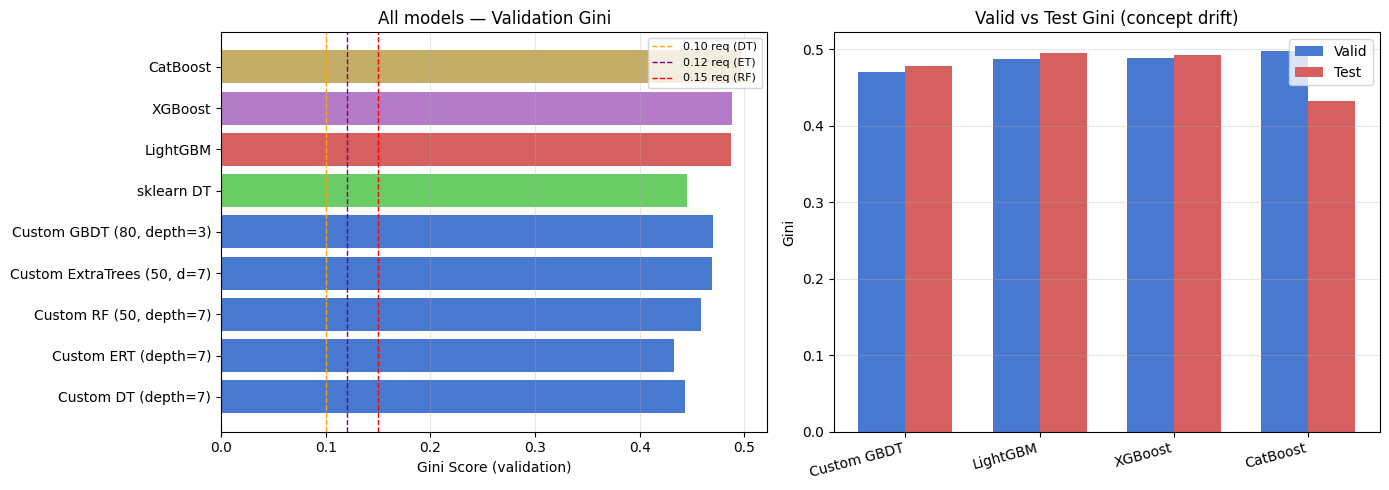

In [ ]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
names = list(all_results.keys())
vals = [all_results[n] for n in names]
colors = ["#4878CF"] * 5 + ["#6ACC65"] + ["#D65F5F", "#B47CC7", "#C4AD66"]
bars = ax.barh(names, vals, color=colors)
ax.axvline(0.10, color="orange", linestyle="--", linewidth=1, label="0.10 req (DT)")
ax.axvline(0.12, color="purple", linestyle="--", linewidth=1, label="0.12 req (ET)")
ax.axvline(0.15, color="red",    linestyle="--", linewidth=1, label="0.15 req (RF)")
ax.set_xlabel("Gini Score (validation)")
ax.set_title("All models — Validation Gini")
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)

ax = axes[1]
top_models = {
    "Custom GBDT": (gini(y_valid, prob_gbdt), gini(y_test, gbdt_custom.predict_proba(X_test)[:, 1])),
    "LightGBM": (gini_lgb, gini(y_test, lgb_model.predict(X_test))),
    "XGBoost": (gini_xgb, gini(y_test, xgb_model.predict(xgb.DMatrix(X_test)))),
    "CatBoost": (gini_cb, gini_test_f),
}
x = np.arange(len(top_models))
w = 0.35
labs = list(top_models.keys())
v_vals = [v for v, t in top_models.values()]
t_vals = [t for v, t in top_models.values()]
ax.bar(x - w/2, v_vals, w, label="Valid", color="#4878CF")
ax.bar(x + w/2, t_vals, w, label="Test",  color="#D65F5F")
ax.set_xticks(x); ax.set_xticklabels(labs, rotation=15, ha="right")
ax.set_ylabel("Gini"); ax.set_title("Valid vs Test Gini (concept drift)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
 
plt.tight_layout()
plt.show()